<a href="https://colab.research.google.com/github/sibinmsd/olist-delivery-analysis/blob/main/Python_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# 🚚 Olist E-Commerce Delivery Performance Analysis

## 📌 Project Overview
This project analyzes the delivery performance of Olist, a Brazilian e-commerce platform,
using ~100,000 orders across multiple datasets. The goal is to identify factors affecting
delivery times and provide actionable business insights.

## 🎯 Objectives
- Measure overall delivery performance (early/on-time/late)
- Identify geographic bottlenecks in delivery
- Analyze impact of product category, price, and freight on delivery
- Correlate delivery performance with customer satisfaction

## 🛠️ Tools Used
- **Python** (Pandas, NumPy)
- **Visualization**: Matplotlib, Seaborn
- **Environment**: Google Colab / Jupyter Notebook

## 📊 Datasets Used
1. Customers
2. Orders
3. Order Items
4. Sellers
5. Products
6. Reviews

Source: [Olist Brazilian E-Commerce Dataset (Kaggle)](https://www.kaggle.com/datasets/olistbr/brazilian-ecommerce)

## 1. Data Loading and Cleaning


In [3]:
import pandas as pd
path = '/content/drive/MyDrive/olist_data/'

customers = pd.read_csv(path + 'olist_customers_dataset.csv')
orders = pd.read_csv(path + 'olist_orders_dataset.csv')
items = pd.read_csv(path + 'olist_order_items_dataset.csv')
sellers = pd.read_csv(path + 'olist_sellers_dataset.csv')
products = pd.read_csv(path + 'olist_products_dataset.csv')
category=pd.read_csv(path + 'product_category_name_translation.csv')
reviews = pd.read_csv(path + 'olist_order_reviews_dataset.csv')
reviews=reviews[['review_id','order_id','review_score']]

print("All files loaded successfully!")


All files loaded successfully!


In [4]:
delivered=orders[orders['order_status']=='delivered'].reset_index()
delivered=delivered.dropna(subset='order_delivered_customer_date')
delivered['order_purchase_timestamp']=pd.to_datetime(delivered['order_purchase_timestamp'],errors='coerce')
delivered['order_approved_at']=pd.to_datetime(delivered['order_approved_at'],errors='coerce')
delivered['order_delivered_carrier_date']=pd.to_datetime(delivered['order_delivered_carrier_date'],errors='coerce')
delivered['order_delivered_customer_date']=pd.to_datetime(delivered['order_delivered_customer_date'],errors='coerce')
delivered['order_estimated_delivery_date']=pd.to_datetime(delivered['order_estimated_delivery_date'],errors='coerce')
items['shipping_limit_date']=pd.to_datetime(items['shipping_limit_date'],errors='coerce')

## 2. Data Merging


In [5]:
def categorize(x):
  if x<0:
    return 'Early'
  elif x>0:
    return 'Late'
  else:
    return 'On time'

co = pd.merge(customers,delivered,on='customer_id')
coi=pd.merge(co,items,on='order_id')
cois=pd.merge(coi,sellers,on='seller_id')
cois['Delivery_days']=(cois['order_delivered_customer_date']-cois['order_purchase_timestamp']).dt.days
cois['Estimated_days']=(cois['order_estimated_delivery_date']-cois['order_purchase_timestamp']).dt.days
cois['Delay_days']=cois['Delivery_days']-cois['Estimated_days']
cois['Delivery_status']=cois['Delay_days'].apply(categorize)

In [6]:
Order_by_status=cois.groupby('Delivery_status')['order_id'].count().reset_index()
Total_Orders=len(cois)
Early_Orders=Order_by_status.loc[Order_by_status['Delivery_status']=='Early','order_id'].values[0]
Late_Orders=Order_by_status.loc[Order_by_status['Delivery_status']=='Late','order_id'].values[0]
Ontime_Orders=Order_by_status.loc[Order_by_status['Delivery_status']=='On time','order_id'].values[0]
Percentage_Early_Orders=round(Early_Orders/Total_Orders*100,2)
Percentage_Late_Orders=round(Late_Orders/Total_Orders*100,2)
Percentage_Ontime_Orders=round(Ontime_Orders/Total_Orders*100,2)
print(f"Percentage of early orders = {Percentage_Early_Orders}%")
print(f"Percentage of late orders = {Percentage_Late_Orders}%")
print(f"Percentage of on time orders = {Percentage_Ontime_Orders}%")

Percentage of early orders = 91.23%
Percentage of late orders = 7.39%
Percentage of on time orders = 1.38%


## 3. Overall Delivery Performance


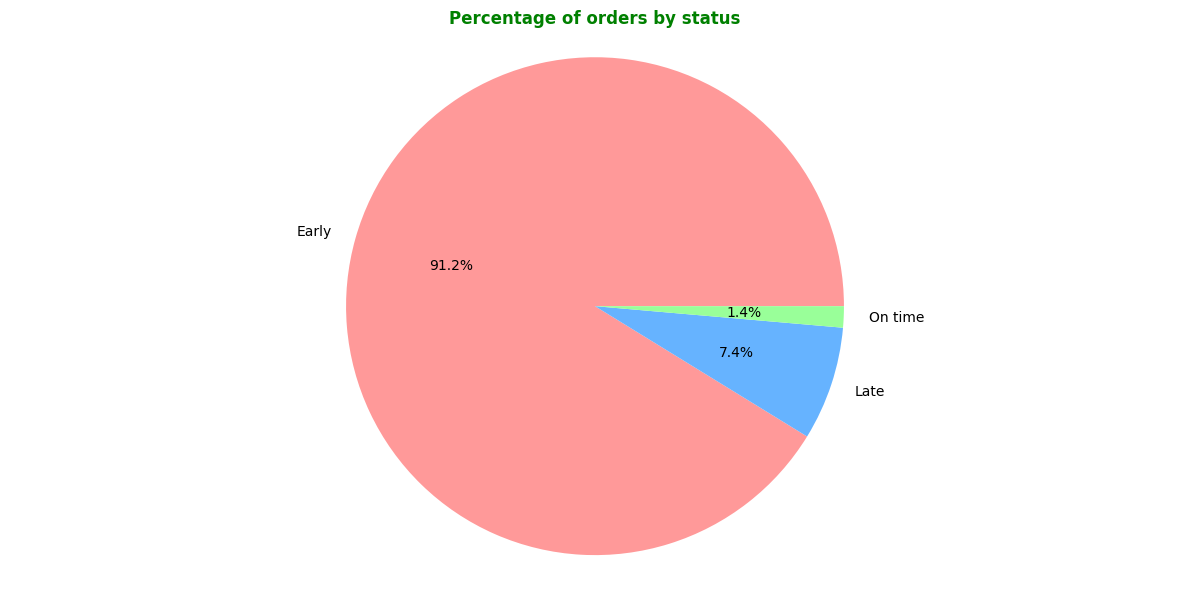

In [88]:
import matplotlib.pyplot as plt
plt.figure(figsize=(12,6))
plt.pie([Percentage_Early_Orders,Percentage_Late_Orders,Percentage_Ontime_Orders],labels=Order_by_status['Delivery_status'],autopct='%1.1f%%',colors=['#ff9999','#66b3ff','#99ff99'])
plt.title('Percentage of orders by status',fontsize=12,fontweight='bold',color='green')
plt.tight_layout()
plt.axis('equal')
plt.show()

### 🔍 Insight
More than 92% of the total orders were delivered on time or early. Only less than 8% of the total orders were late. This shows olist are meeting the estimated deadline with 92% accuracy.


## 4. Geographic Analysis
   ### 4.1 City-wise Performance
   


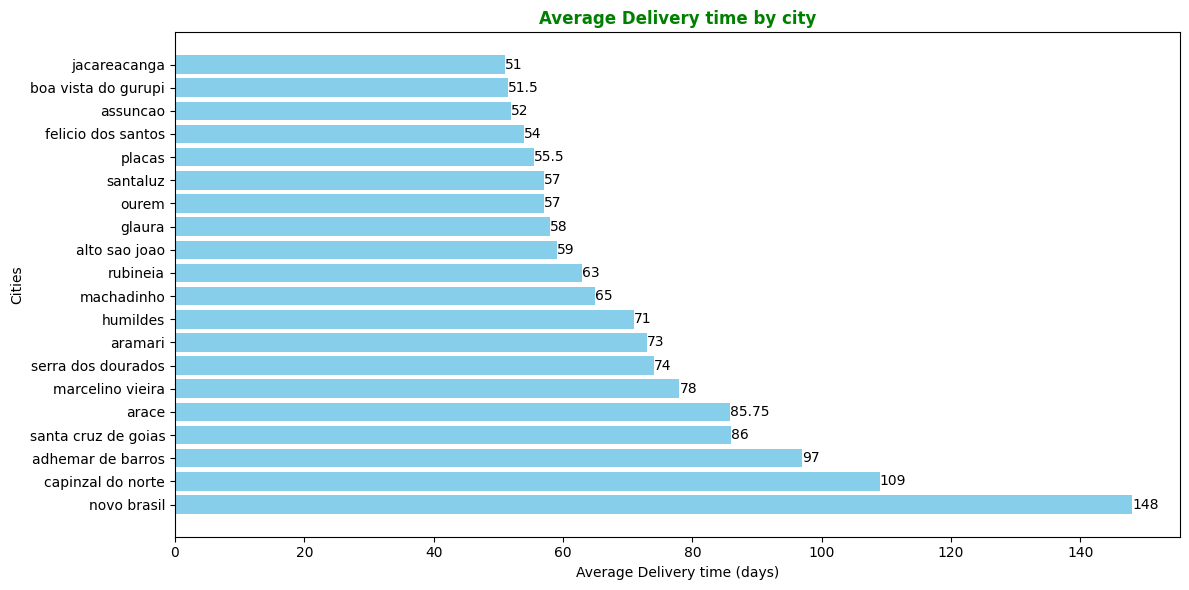

In [89]:
city_delivery=cois.groupby('customer_city')['Delivery_days'].mean().reset_index()
city_delivery=city_delivery.sort_values(by='Delivery_days',ascending=False)
c_d=city_delivery.head(20).reset_index()
plt.figure(figsize=(12,6))
bars=plt.barh(c_d['customer_city'],c_d['Delivery_days'],color='skyblue')
plt.title('Average Delivery time by city',fontsize=12,fontweight='bold',color='green')
plt.xlabel('Average Delivery time (days)')
plt.ylabel('Cities')
plt.bar_label(bars)
plt.tight_layout()
plt.show()

### 🔍 Insight
Average delivery time of orders to North and Northeastern cities (50-100 days) is almost 100% more than the delivery time to southern cities, because delivery hubs are more concentrated on southern states.

### 4.2 State-wise Performance
   

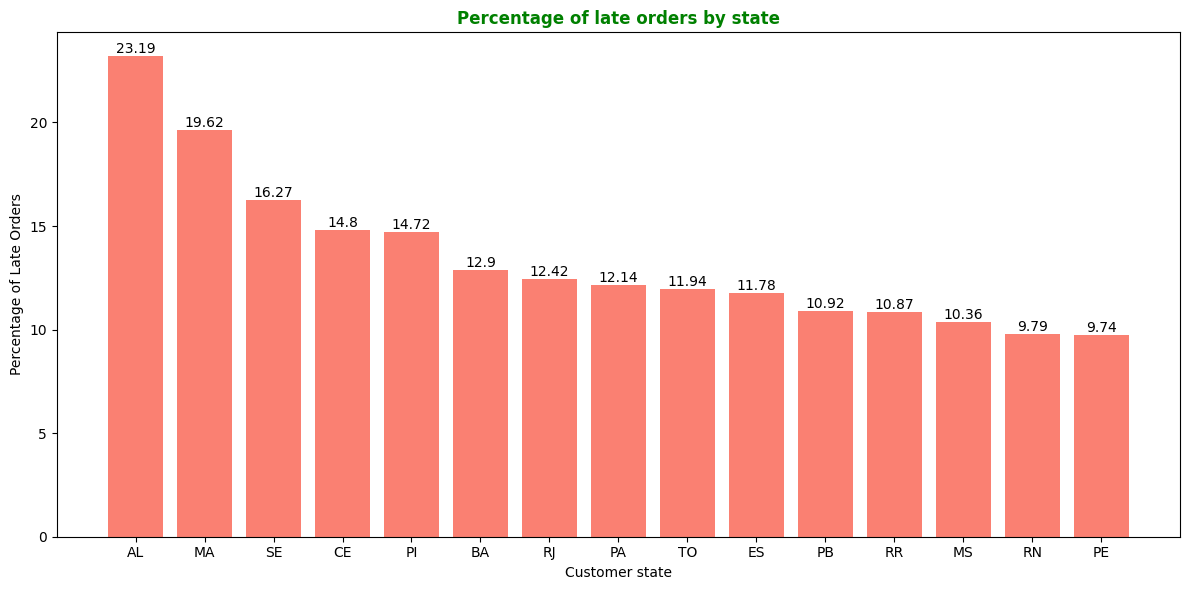

In [90]:
state_status=cois.groupby(['customer_state','Delivery_status'])['order_id'].count().reset_index()
state_late=state_status[state_status['Delivery_status']=='Late'].reset_index()
state_total=cois.groupby('customer_state')['order_id'].count().reset_index()
state_total['Late_percentage']=round(state_late['order_id']/state_total['order_id']*100,2)
state_total=state_total.sort_values(by='Late_percentage',ascending=False)
state_total=state_total.head(15).reset_index()
plt.figure(figsize=(12,6))
bars=plt.bar(state_total['customer_state'],state_total['Late_percentage'],color='salmon')
plt.title('Percentage of late orders by state',fontsize=12,fontweight='bold',color='green')
plt.xlabel('Customer state')
plt.ylabel('Percentage of Late Orders')
plt.bar_label(bars)
plt.tight_layout()
plt.show()

### 🔍 Insight
Percentage of late orders is 50% more in Northern and Northeastern states when compared to the Souther states because of 80% of the high volume sellers are in southern states.

### 4.3 Route Analysis

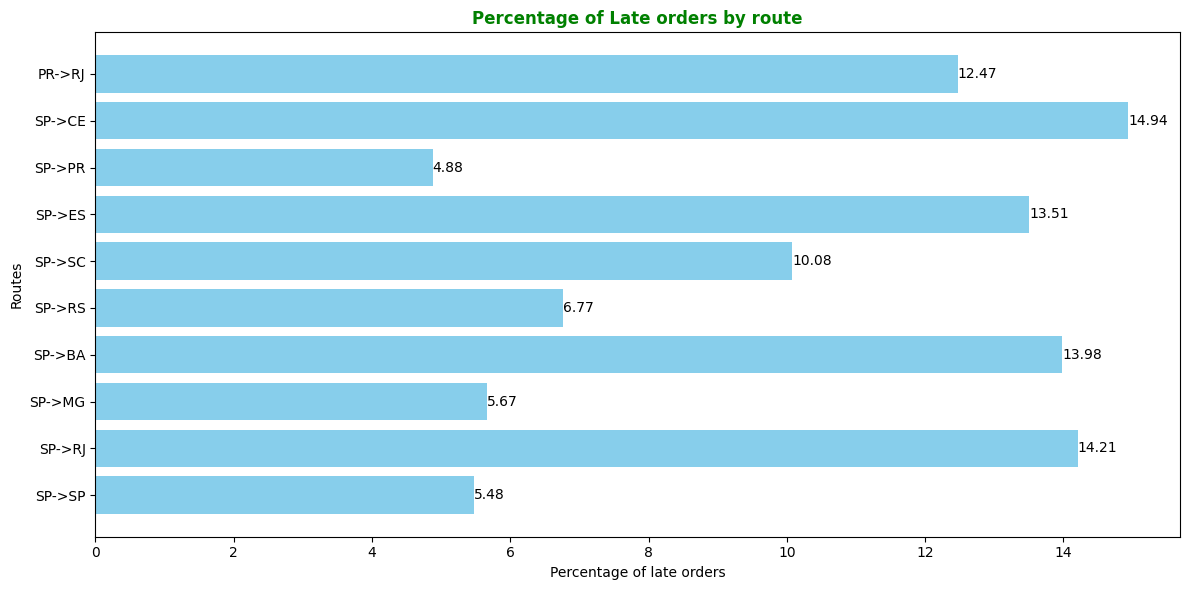

In [91]:
order_route=cois.groupby(['seller_state','customer_state','Delivery_status'])['order_id'].count().reset_index()
order_route=order_route[order_route['Delivery_status']=='Late']
order_route['route']=order_route['seller_state'] + '->' + order_route['customer_state']
order_route_total=cois.groupby(['seller_state','customer_state'])['order_id'].count().reset_index()
order_route_total['route']=order_route_total['seller_state'] + '->' + order_route_total['customer_state']
order_route=pd.merge(order_route,order_route_total,on='route')
order_route['Late_Percentage']=round(order_route['order_id_x']/order_route['order_id_y']*100,2)
order_route=order_route.sort_values(by='order_id_x',ascending=False).head(10)
plt.figure(figsize=(12,6))
bars=plt.barh(order_route['route'],order_route['Late_Percentage'],color='skyblue')
plt.title('Percentage of Late orders by route',fontsize=12,fontweight='bold',color='green')
plt.xlabel('Percentage of late orders')
plt.ylabel('Routes')
plt.bar_label(bars)
plt.tight_layout()
plt.show()

### 🔍 Insight
Sao Paulo is the central hub of olist and more than 80% of delivery routes from Sao Paulo to Northern states experience delays as one-tenth of total orders are delayed.

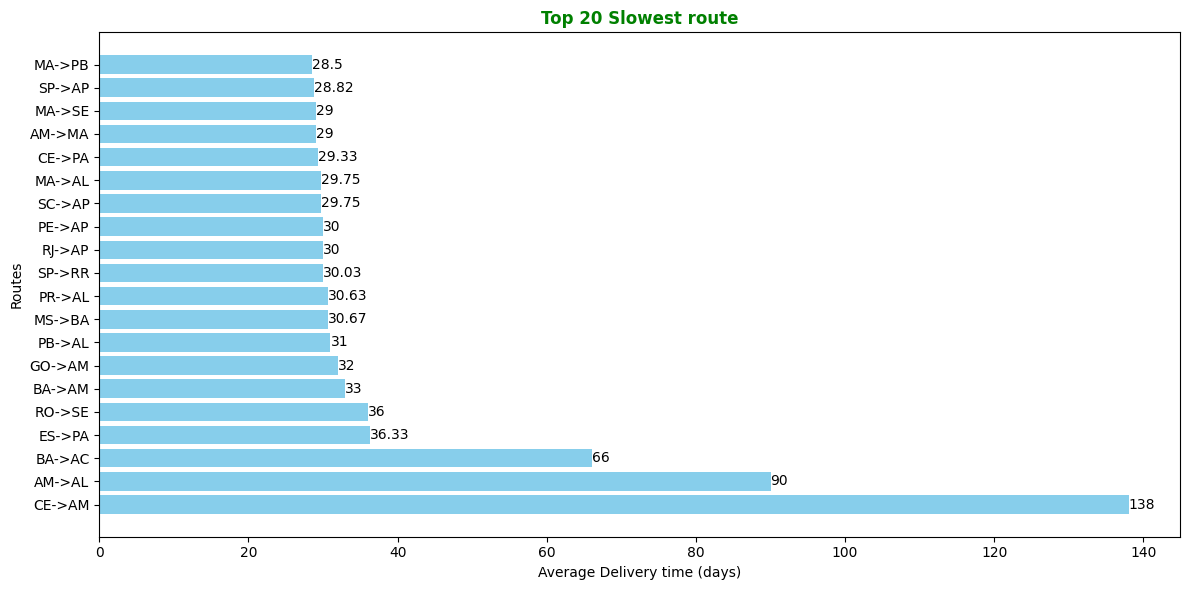

In [92]:
route_days=cois.groupby(['seller_state','customer_state'])['Delivery_days'].mean().round(2).reset_index()
route_days=route_days.sort_values(by='Delivery_days',ascending=False).head(20)
route_days['route']=route_days['seller_state'] + '->' + route_days['customer_state']
route_days
plt.figure(figsize=(12,6))
bars=plt.barh(route_days['route'],route_days['Delivery_days'],color='skyblue')
plt.title('Top 20 Slowest route',fontsize=12,fontweight='bold',color='green')
plt.xlabel('Average Delivery time (days)')
plt.ylabel('Routes')
plt.bar_label(bars)
plt.tight_layout()
plt.show()


### 🔍 Insight
Average delivery time of routes involving Amazonian states (AM, AC, AL) is almost two times of the average delivery time taken by remaining routes mainly due to the river logistics.

## 4.4 Seller state & customer state correlation

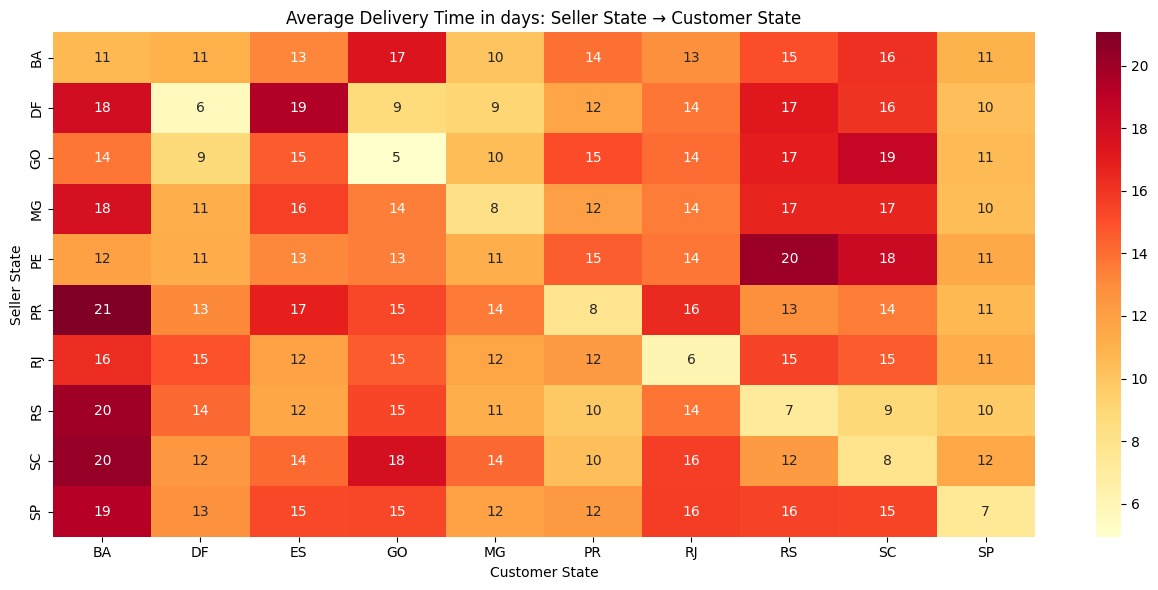

In [96]:
import seaborn as sns
top_sellers=cois['seller_state'].value_counts().head(10).index.tolist()
top_customers=cois['customer_state'].value_counts().head(10).index.tolist()
route_heat=cois.groupby(['seller_state','customer_state'])['Delivery_days'].mean().reset_index()
route_top=route_heat[(route_heat['seller_state'].isin(top_sellers))&(route_heat['customer_state'].isin(top_customers))]
piv=route_top.pivot(index='seller_state',columns='customer_state',values='Delivery_days')
plt.figure(figsize=(13,6))
sns.heatmap(piv,annot=True,cmap='YlOrRd',fmt='0.0f')
plt.title('Average Delivery Time in days: Seller State → Customer State')
plt.xlabel('Customer State')
plt.ylabel('Seller State')
plt.tight_layout()
plt.show()

### 🔍 Insight
For states with high volume of orders, inter-state deliveries are faster and takes less than 10 days on average. GO-GO interstate deliveries are faster with average delivery time of 5 days.

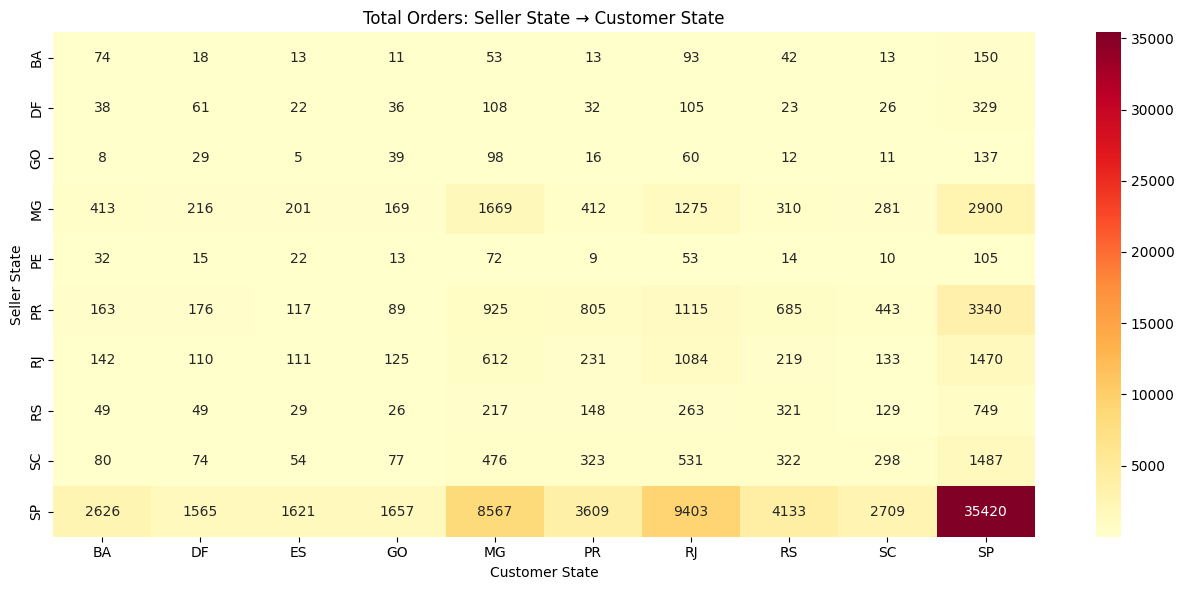

In [97]:
route_orders=cois.groupby(['seller_state','customer_state'])['order_id'].count().reset_index()
route_top_o=route_orders[(route_orders['seller_state'].isin(top_sellers))&(route_orders['customer_state'].isin(top_customers))]
piv=route_top_o.pivot(index='seller_state',columns='customer_state',values='order_id')
plt.figure(figsize=(13,6))
sns.heatmap(piv,annot=True,cmap='YlOrRd',fmt='0.0f')
plt.title('Total Orders: Seller State → Customer State')
plt.xlabel('Customer State')
plt.ylabel('Seller State')
plt.tight_layout()
plt.show()

### 🔍 Insight
Southeast region is the main selling market with states such as Sao Paulo, Rio De Jeneiro, Minas Gerais, Rio Grande do Sul constitute 60% to the total sales.

## 5. Monthly Trends   


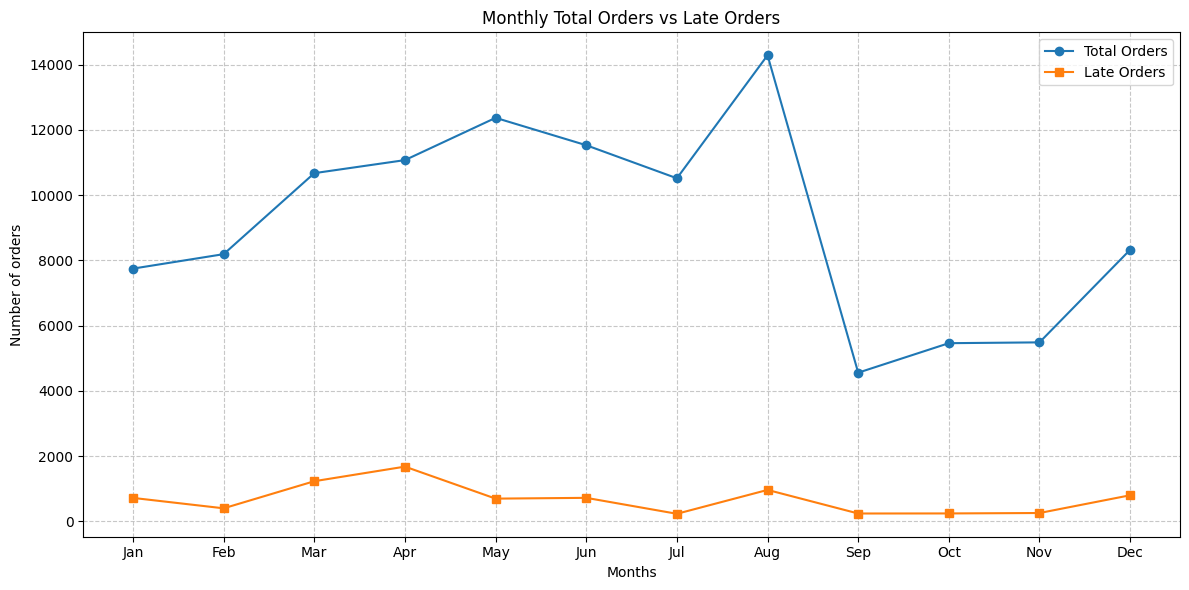

In [98]:
monthwise_orders=cois.groupby(cois['order_delivered_customer_date'].dt.month)['order_id'].count().reset_index()
late_orders=cois.groupby([cois['order_delivered_customer_date'].dt.month,'Delivery_status'])['order_id'].count().reset_index()
late_orders=late_orders[late_orders['Delivery_status']=='Late']
months=['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
plt.figure(figsize=(12,6))
plt.plot(months,monthwise_orders['order_id'],marker='o',label='Total Orders')
plt.plot(months,late_orders['order_id'],marker='s',label='Late Orders')
plt.title("Monthly Total Orders vs Late Orders")
plt.xlabel("Months")
plt.ylabel("Number of orders")
plt.grid(linestyle='--',alpha=0.7)
plt.tight_layout()
plt.legend()
plt.show()


### 🔍 Insight
A 4-5% spike in late orders on March and April is mainly due to the cultural festivals celebrated in the month of February (Carnival) and Easter in April.A 50% spike in total orders in the month of August is mainly due to one of the biggest retail e-commercent event associated with Father's day.The total sales dipped by almost 70% in the month of September

## 6. Product Category Analysis


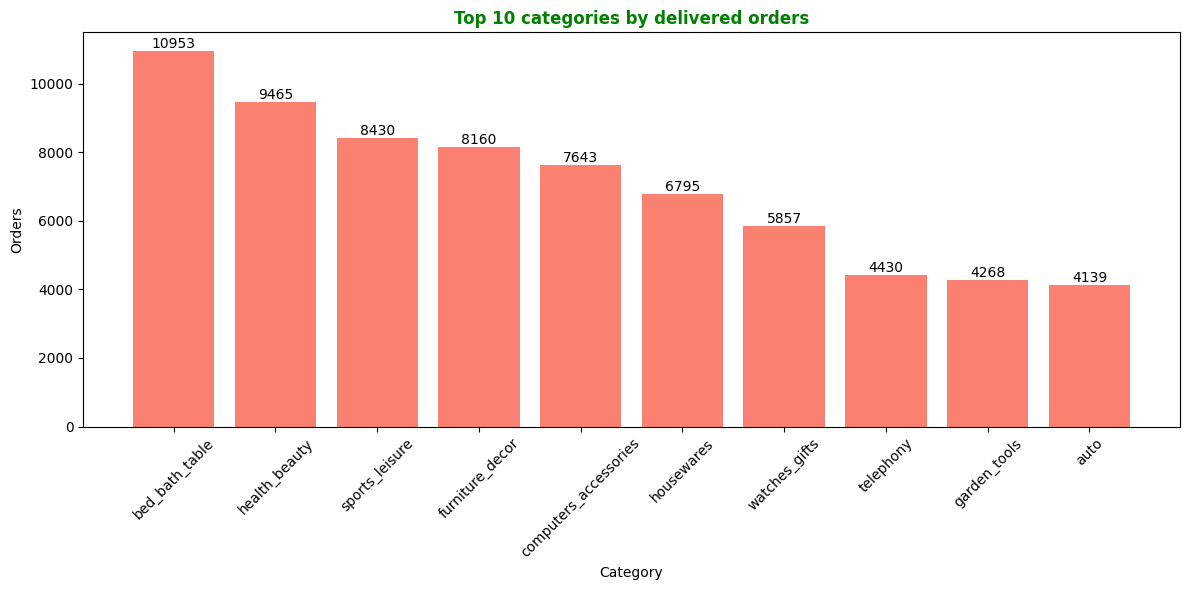

In [99]:
products_category=pd.merge(products,category,on='product_category_name')
products_category=products_category[['product_id','product_category_name_english']]
merged=pd.merge(cois,products_category,on='product_id')
category_orders=merged.groupby('product_category_name_english')['product_id'].count().reset_index()
category_orders=category_orders.sort_values(by='product_id',ascending=False).head(10)
plt.figure(figsize=(12,6))
bars=plt.bar(category_orders['product_category_name_english'],category_orders['product_id'],color='salmon')
plt.title("Top 10 categories by delivered orders",fontsize=12,fontweight='bold',color='green')
plt.xlabel("Category")
plt.xticks(rotation=45)
plt.ylabel("Orders")
plt.bar_label(bars)
plt.tight_layout()
plt.grid(False)
plt.show()

### 🔍 Insight
Home and living essential products as well as personal health care products constitute more than 50% of the total products being sold

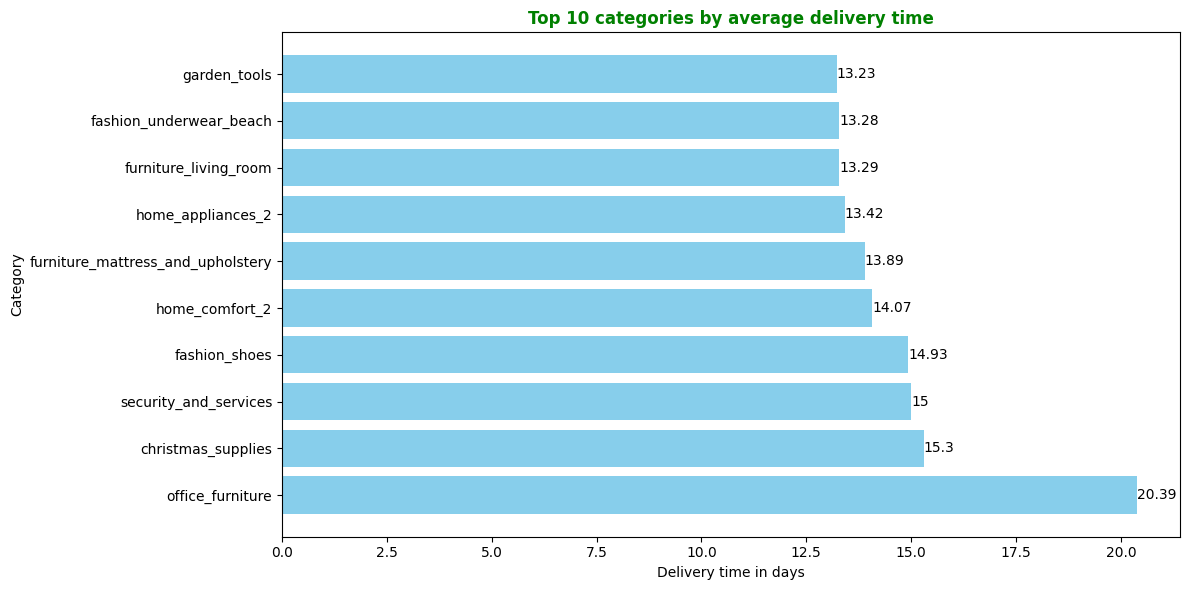

In [100]:
category_days=merged.groupby('product_category_name_english')['Delivery_days'].mean().round(2).reset_index()
category_days=category_days.sort_values(by='Delivery_days',ascending=False).head(10)
plt.figure(figsize=(12,6))
bars=plt.barh(category_days['product_category_name_english'],category_days['Delivery_days'],color='skyblue')
plt.title("Top 10 categories by average delivery time",fontsize=12,fontweight='bold',color='green')
plt.ylabel("Category")
plt.xlabel("Delivery time in days")
plt.bar_label(bars)
plt.tight_layout()
plt.grid(False)
plt.show()

### 🔍 Insight
Average delivery time for products which are larger in size is 15-20 days which is 40-50% higher than the usual products.

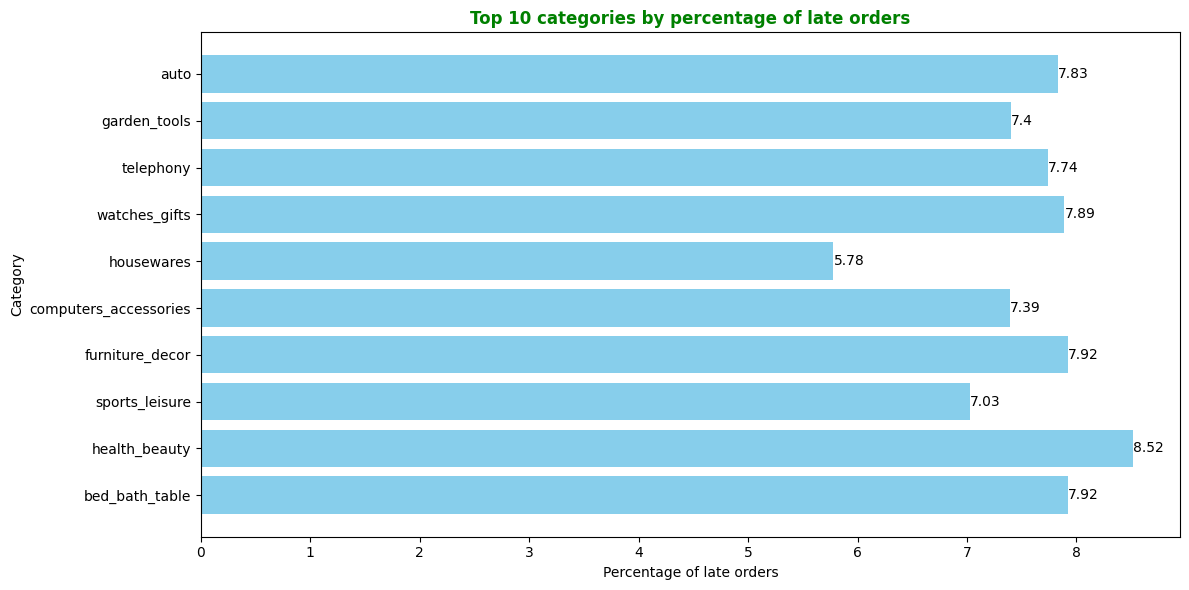

In [101]:
category_total=merged.groupby('product_category_name_english')['order_id'].count().reset_index()
category_late=merged.groupby(['product_category_name_english','Delivery_status'])['order_id'].count().reset_index()
category_late=category_late[category_late['Delivery_status']=='Late']
category_merged=pd.merge(category_late,category_total,on='product_category_name_english')
category_merged['Late_percentage']=round(category_merged['order_id_x']/category_merged['order_id_y']*100,2)
category_merged=category_merged.sort_values(by='order_id_y',ascending=False).head(10)
plt.figure(figsize=(12,6))
bars=plt.barh(category_merged['product_category_name_english'],category_merged['Late_percentage'],color='skyblue')
plt.title("Top 10 categories by percentage of late orders",fontsize=12,fontweight='bold',color='green')
plt.ylabel("Category")
plt.xlabel("Percentage of late orders")
plt.bar_label(bars)
plt.tight_layout()
plt.grid(False)
plt.show()


### 🔍 Insight
The best selling product categories experience 6-7% late deliveries on average

## 7. Price & Freight Analysis


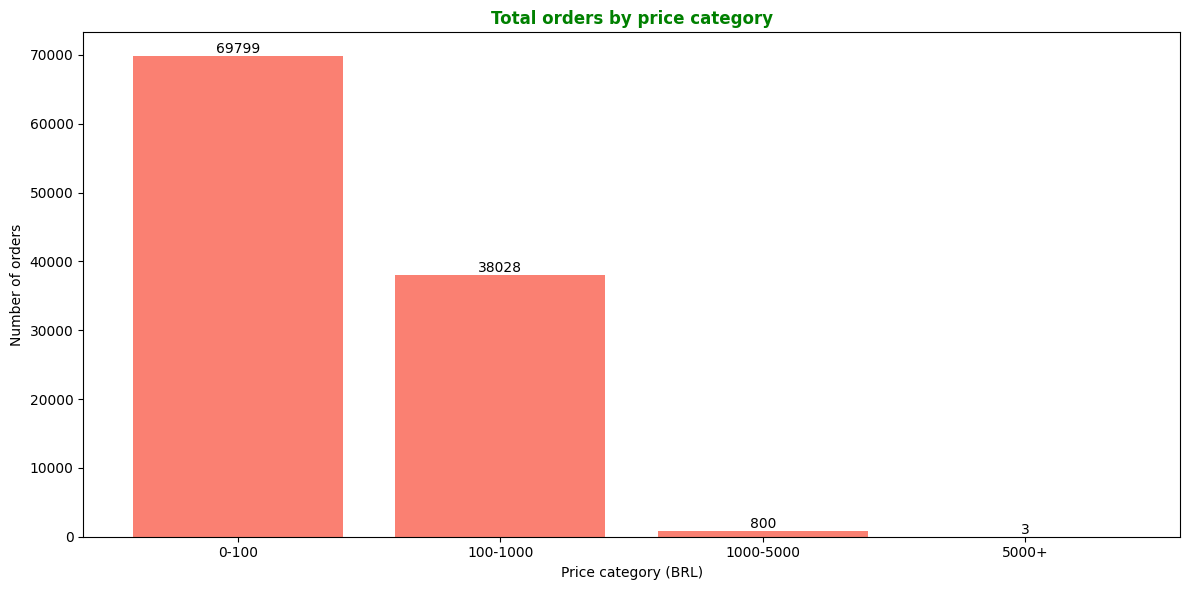

In [102]:
def cat(x):
  if x<100:
    return '0-100'
  elif x<1000:
    return '100-1000'
  elif x<=5000:
    return '1000-5000'
  else:
    return '5000+'
merged['price_category']=merged['price'].apply(cat)
pricewise_orders=merged.groupby('price_category')['order_id'].count().reset_index()
plt.figure(figsize=(12,6))
bars=plt.bar(pricewise_orders['price_category'],pricewise_orders['order_id'],color='salmon')
plt.title("Total orders by price category",fontsize=12,fontweight='bold',color='green')
plt.xlabel("Price category (BRL)")
plt.ylabel("Number of orders")
plt.bar_label(bars)
plt.tight_layout()
plt.show()

### 🔍 Insight
Low cost products are the most popular as more than 95% of the total orders are priced at 0-1000 BRL

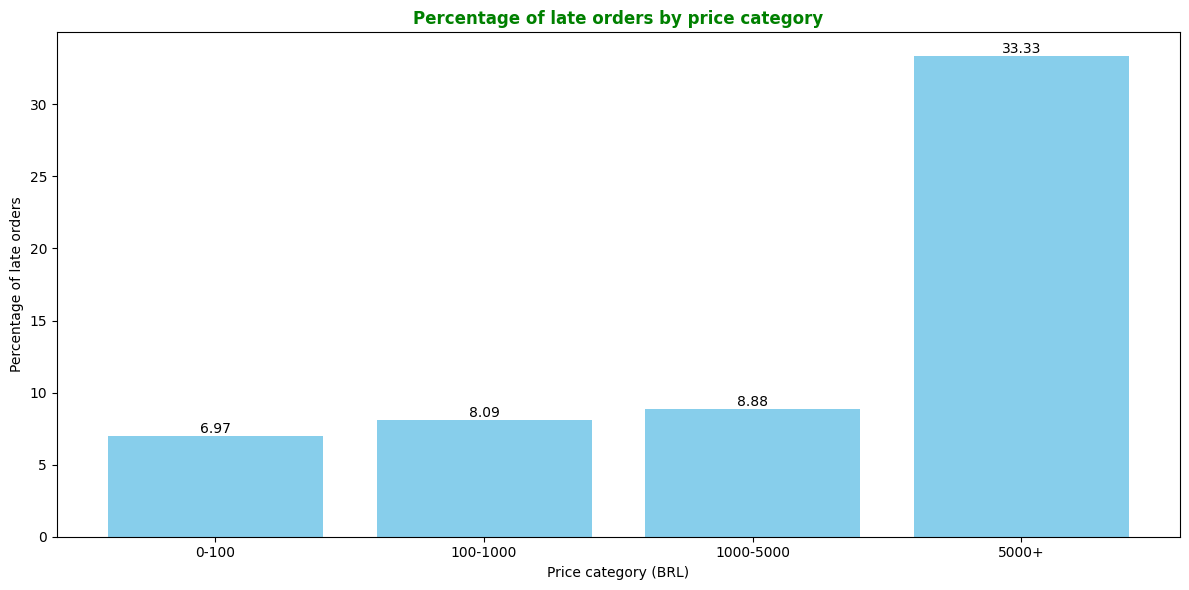

In [103]:
pricewise_total_orders=merged.groupby('price_category')['order_id'].count().reset_index()
pricewise_late_orders=merged.groupby(['price_category','Delivery_status'])['order_id'].count().reset_index()
pricewise_late_orders=pricewise_late_orders[pricewise_late_orders['Delivery_status']=='Late']
pricewise_merged=pd.merge(pricewise_late_orders,pricewise_total_orders,on='price_category')
pricewise_merged['Late_percentage']=round(pricewise_merged['order_id_x']/pricewise_merged['order_id_y']*100,2)
pricewise_merged=pricewise_merged.sort_values(by='order_id_x',ascending=False)
plt.figure(figsize=(12,6))
bars=plt.bar(pricewise_merged['price_category'],pricewise_merged['Late_percentage'],color='skyblue')
plt.title("Percentage of late orders by price category",fontsize=12,fontweight='bold',color='green')
plt.xlabel("Price category (BRL)")
plt.ylabel("Percentage of late orders")
plt.bar_label(bars)
plt.tight_layout()
plt.show()

### 🔍 Insight
Out of total orders, more than 90% of the product are low cost orders (0-1000) and on average 7.5% of these low cost orders are delayed which is about 8000 orders.

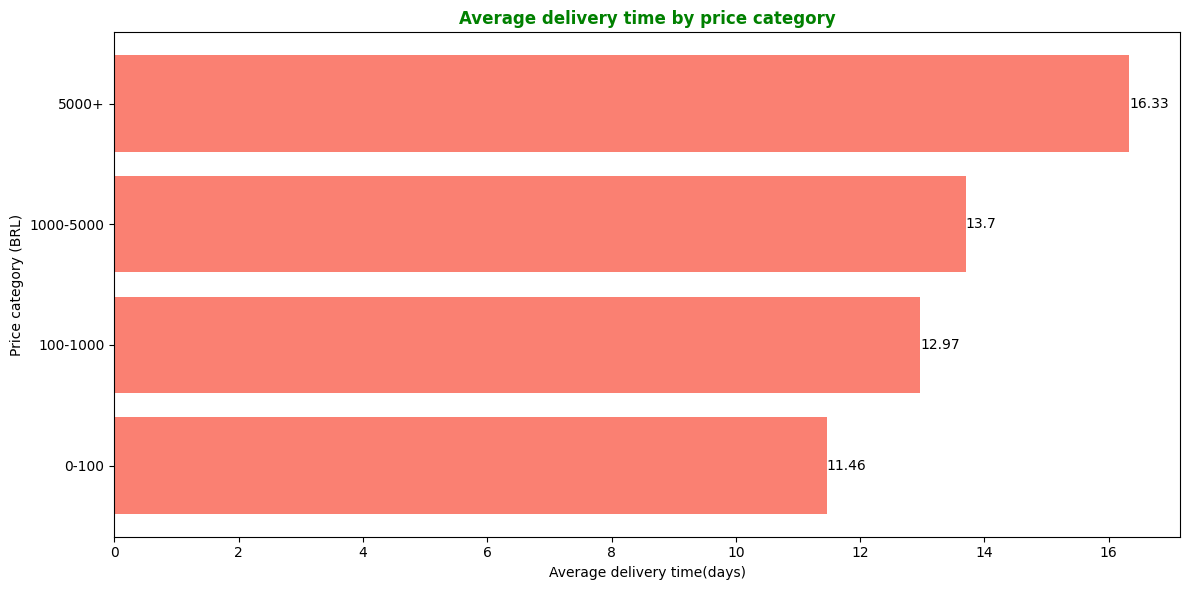

In [104]:
pricewise_days=merged.groupby('price_category')['Delivery_days'].mean().round(2).reset_index()
plt.figure(figsize=(12,6))
bars=plt.barh(pricewise_days['price_category'],pricewise_days['Delivery_days'],color='salmon')
plt.title("Average delivery time by price category",fontsize=12,fontweight='bold',color='green')
plt.ylabel("Price category (BRL)")
plt.xlabel("Average delivery time(days)")
plt.bar_label(bars)
plt.tight_layout()
plt.show()

### 🔍 Insight
Despite high volume of low cost products being ordered the average delivery tme is 10-12 days which is 2-3 days lower than high cost products.

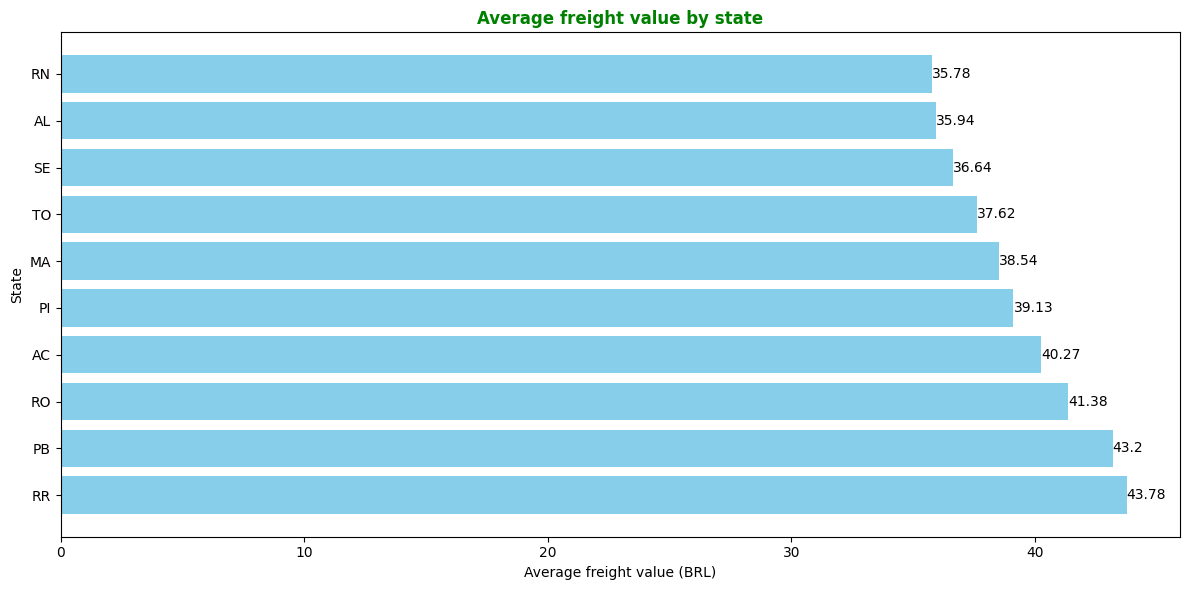

In [105]:
state_freight=merged.groupby('customer_state')['freight_value'].mean().round(2).reset_index()
state_freight=state_freight.sort_values(by='freight_value',ascending=False)
top_freight=state_freight.head(10).reset_index()
plt.figure(figsize=(12,6))
bars=plt.barh(top_freight['customer_state'],top_freight['freight_value'],color='skyblue')
plt.title("Average freight value by state",fontsize=12,fontweight='bold',color='green')
plt.ylabel("State")
plt.xlabel("Average freight value (BRL)")
plt.bar_label(bars)
plt.tight_layout()
plt.show()

### 🔍 Insight
Shipping cost for North and Northeastern regions (RR, PB, RO) is 20-25% more than that of southern regions due to transportation constraints.

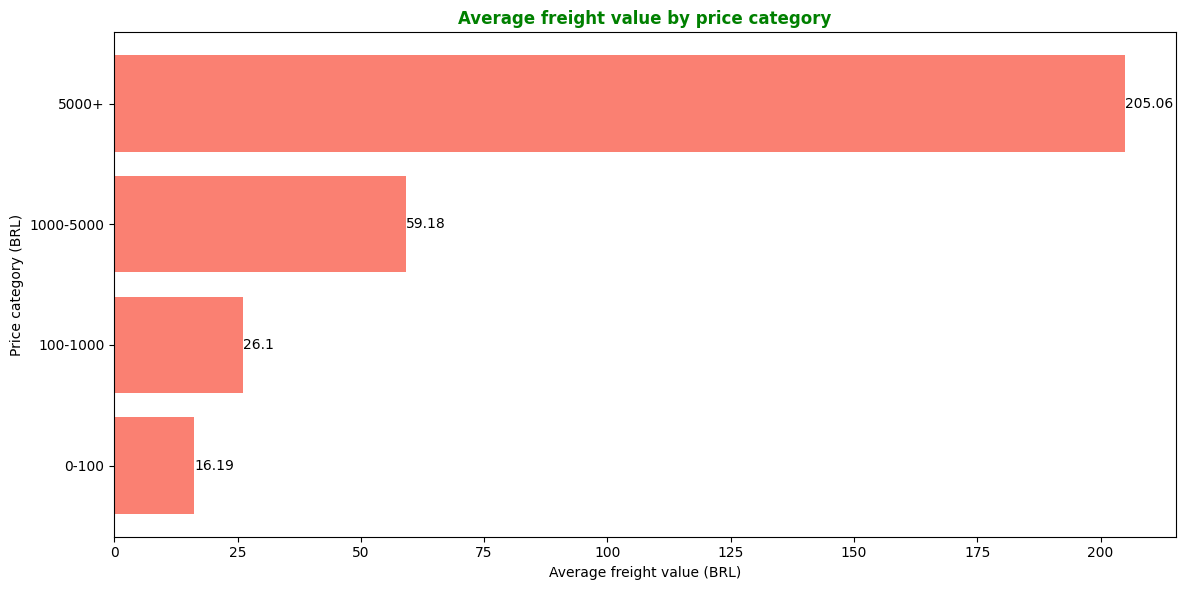

In [106]:
pricewise_freight=merged.groupby('price_category')['freight_value'].mean().round(2).reset_index()
plt.figure(figsize=(12,6))
bars=plt.barh(pricewise_freight['price_category'],pricewise_freight['freight_value'],color='salmon')
plt.title("Average freight value by price category",fontsize=12,fontweight='bold',color='green')
plt.ylabel("Price category (BRL)")
plt.xlabel("Average freight value (BRL)")
plt.bar_label(bars)
plt.tight_layout()
plt.show()

### 🔍 Insight
The average shipping cost of best selling products (Price range 0-1000) is 18-25 BRL which is half of the average shipping cost of highly priced products (1000+ BRL)

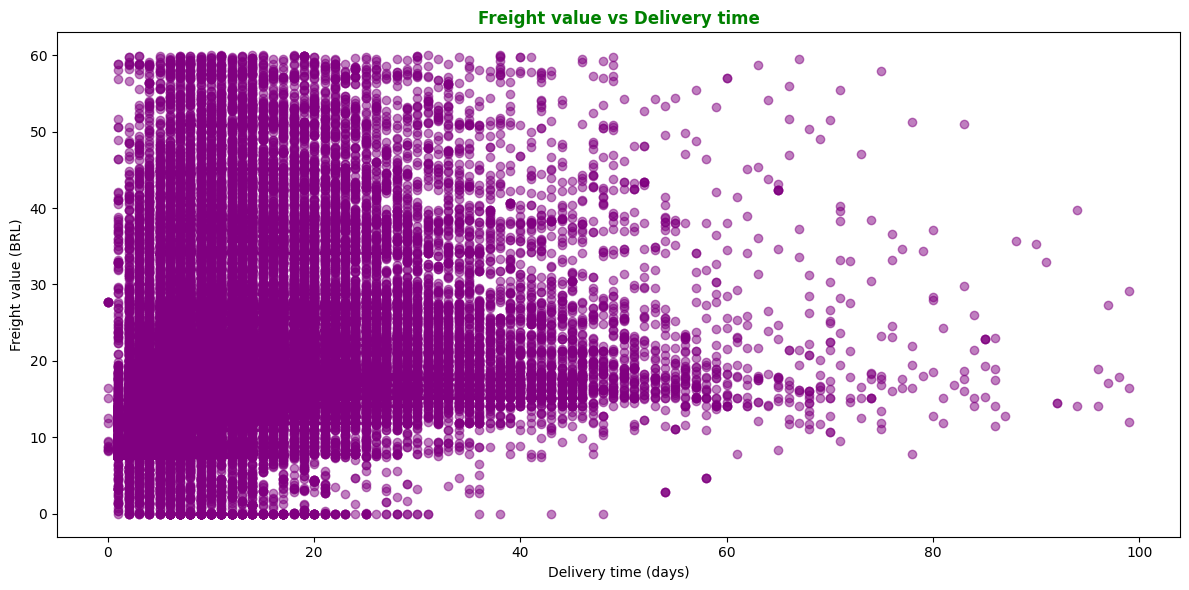

In [107]:
filtered_data=merged[(merged['Delivery_days']<100)&(merged['freight_value']<60)]
plt.figure(figsize=(12,6))
plt.scatter(filtered_data['Delivery_days'],filtered_data['freight_value'],color='purple',alpha=0.5)
plt.title("Freight value vs Delivery time",fontsize=12,fontweight='bold',color='green')
plt.xlabel("Delivery time (days)")
plt.ylabel("Freight value (BRL)")
plt.tight_layout()
plt.show()


### 🔍 Insight
For orders with delivery days greater than 30 days, the shipping cost is in the range 10-40 BRL. For 90% of the orders with longer delivery time (>60 days), the shipping cost is in the range 20-60 BRL.

## 8. Review Score Correlation


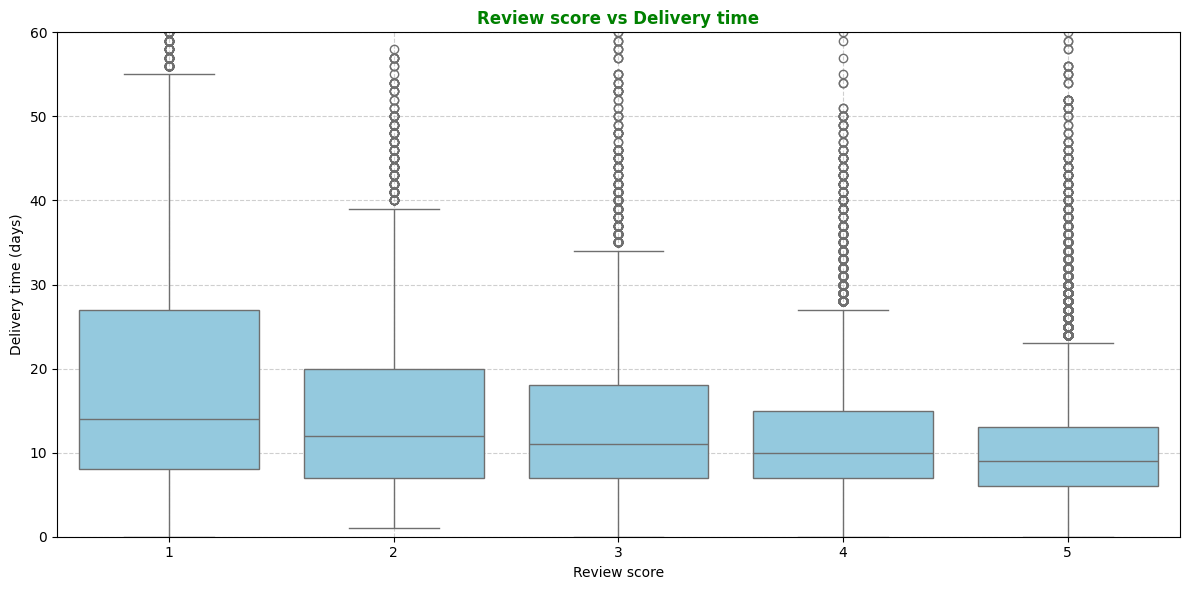

In [108]:
review_merged=pd.merge(merged,reviews,on='order_id')
plt.figure(figsize=(12,6))
sns.boxplot(data=review_merged,x=review_merged['review_score'],y=review_merged['Delivery_days'],color='skyblue')
plt.title("Review score vs Delivery time",fontsize=12,fontweight='bold',color='green')
plt.xlabel("Review score")
plt.ylabel("Delivery time (days)")
plt.grid(linestyle='--',alpha=0.6)
plt.ylim(0,60)
plt.tight_layout()
plt.show()

### 🔍 Insight
Average delivery time for low rated products are 10-25 days whereas high rated products are mostly delivered within 8-13 days.

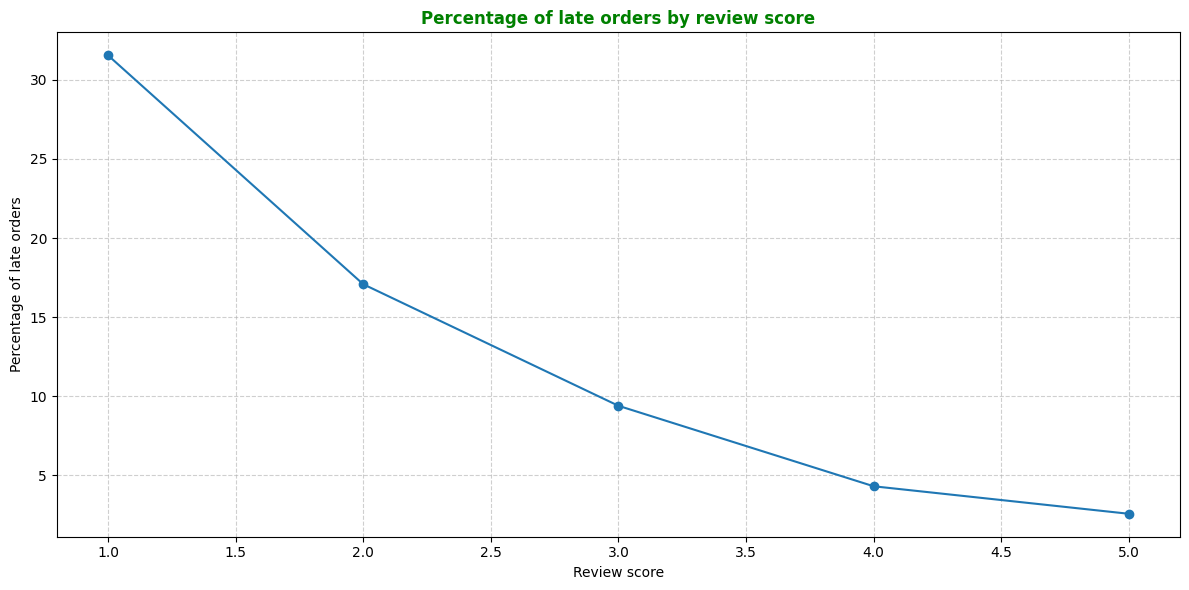

In [109]:
review_orders=review_merged.groupby('review_score')['order_id'].count().reset_index()
review_late=review_merged.groupby(['review_score','Delivery_status'])['order_id'].count().reset_index()
review_late=review_late[review_late['Delivery_status']=='Late']
review_orders_late=pd.merge(review_orders,review_late,on='review_score')
review_orders_late['Late_percentage']=round(review_orders_late['order_id_y']/review_orders_late['order_id_x']*100,2)
plt.figure(figsize=(12,6))
plt.plot(review_orders_late['review_score'],review_orders_late['Late_percentage'],marker='o')
plt.title("Percentage of late orders by review score",fontsize=12,fontweight='bold',color='green')
plt.xlabel("Review score")
plt.ylabel("Percentage of late orders")
plt.grid(linestyle='--',alpha=0.6)
plt.tight_layout()
plt.show()

### 🔍 Insight
More than 80% of the total orders are top rated and out of top rated products only 5% of the orders are delivered after the estimated date.  

## 9. Key Findings & Recommendations

## 🎯 Key Findings

1. **Overall Performance**: 92% of orders were delivered early or on-time, while 8% were late.

2. **Geographic Bottleneck**: Northern states (AC, AM, RR, AP) have average delivery times
   of 25-35 days, compared to 8-12 days for Southeast states.

3. **Best Route**: GO → GO is the fastest route (5 days average) due to logistics hub.

4. **Product Impact**: Furniture and office category have the highest average delivery time (~20 days).

5. Freight value and delivery time are not linearly dependent, however for longer delivery time (>60 days) average freight values is approximately 20-40 BRL

6. **Satisfaction Impact**: 1-star reviews have a 35% late delivery rate,
   while 5-star reviews only have 3% — proving delivery directly impacts satisfaction.

## 💡 Recommendations

1. **Regional Warehouses**: Establish fulfillment centers in Northern regions.
2. **Better Delivery Estimates**: Adjust estimated dates for remote destinations.
3. **Category-specific SLAs**: Set realistic delivery times for bulky items.
4. **Freight Subsidy**: Consider partial subsidies for high-cost regions.
5. **Priority Handling**: Flag orders to remote regions for expedited processing.